# Week 10 - Regression Model
This week, you will learn to run a Multiple Regression Model.  When you are trying to predict a continuous variable you are building a regression model.  This week you will use the Boston Housing Data set with the B and CHAS columns deleted.<br>

- CRIM - per capita crime rate by town
- ZN - proportion of residential land zoned for lots over 25,000 sq.ft.
- INDUS - proportion of non-retail business acres per town.
- CHAS - Charles River dummy variable (1 if tract bounds river; 0 otherwise)
- NOX - nitric oxides concentration (parts per 10 million)
- RM - average number of rooms per dwelling
- AGE - proportion of owner-occupied units built prior to 1940
- DIS - weighted distances to five Boston employment centres
- RAD - index of accessibility to radial highways
- TAX - full-value property-tax rate per 10,000 dollars
- PTRATIO - pupil-teacher ratio by town
- B - 1000(Bk - 0.63)^2, where Bk is the proportion of blacks by town
- LSTAT - % lower status of the population
- MEDV - Median value of owner-occupied homes in $1000's


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as so


In [2]:
# Read in the dataset
boston = pd.read_csv("boston_clean.csv")
boston.head()

,Unnamed,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0,0.00632,18.0,-2.31,NaN,0.538,NaN,65.2,4.0900,1.0,NaN,15.3,NaN,4.98,24.0
1,1,0.02731,0.0,7.07,Other,NaN,NaN,78.9,4.9671,2.0,242,17.8,NaN,NaN,21.6
2,2,NaN,0.0,7.07,Other,0.469,7.185,61.1,4.9671,2.0,NaN,NaN,NaN,NaN,34.7
3,3,0.03237,0.0,2.18,Other,NaN,6.998,45.8,6.0622,3.0,222',NaN,394.63,NaN,33.4
4,4,0.06905,0.0,2.18,Other,NaN,7.147,NaN,6.0622,NaN,222',NaN,NaN,NaN,36.2


# Drop Unnamed, B, RAD, and CHAS columns

In [3]:
LN = ['Unnamed', 'B', 'RAD', 'CHAS']
boston.drop(columns = LN, axis = 1, inplace = True)

In [4]:
boston.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 11 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     456 non-null    float64
 1   ZN       463 non-null    float64
 2   INDUS    506 non-null    float64
 3   NOX      328 non-null    float64
 4   RM       329 non-null    float64
 5   AGE      317 non-null    float64
 6   DIS      339 non-null    float64
 7   TAX      336 non-null    object 
 8   PTRATIO  331 non-null    float64
 9   LSTAT    321 non-null    float64
 10  MEDV     506 non-null    float64
dtypes: float64(10), object(1)
memory usage: 43.6+ KB


In [5]:
# Delete Duplicate Records
boston_dup = boston[boston.duplicated(keep = 'first')]
if boston_dup.size != 0:
    boston.drop_duplicates(keep = 'first', ignore_index = True, inplace = True)
boston.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 11 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     456 non-null    float64
 1   ZN       463 non-null    float64
 2   INDUS    506 non-null    float64
 3   NOX      328 non-null    float64
 4   RM       329 non-null    float64
 5   AGE      317 non-null    float64
 6   DIS      339 non-null    float64
 7   TAX      336 non-null    object 
 8   PTRATIO  331 non-null    float64
 9   LSTAT    321 non-null    float64
 10  MEDV     506 non-null    float64
dtypes: float64(10), object(1)
memory usage: 43.6+ KB


In [6]:
boston['TAX'].unique()

array([nan, '242', "222'", '311', '307', '279', '252', '233', '243',
       '469', '313', '256', '284', '337', '345', '305', '398', '281',
       '247', '270', '276', '384', '432', '188', '437', '403', '296',
       '193', '265', '329', '402', '348', '224', '277', '300', '330',
       '315', '264', '223', '254', '216', '198', '285', '241', '293',
       '245', '289', '358', '222', '304', '287', '422', '370', '352',
       '351', '280', '335', '411', '334', '666', '711', '391', '273'],
      dtype=object)

In [7]:
boston.loc[boston['TAX'] == "222'", "TAX"] = '222'
boston['TAX'] = boston['TAX'].astype(float)
boston.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 11 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     456 non-null    float64
 1   ZN       463 non-null    float64
 2   INDUS    506 non-null    float64
 3   NOX      328 non-null    float64
 4   RM       329 non-null    float64
 5   AGE      317 non-null    float64
 6   DIS      339 non-null    float64
 7   TAX      336 non-null    float64
 8   PTRATIO  331 non-null    float64
 9   LSTAT    321 non-null    float64
 10  MEDV     506 non-null    float64
dtypes: float64(11)
memory usage: 43.6 KB


In [8]:
num_cols = boston.select_dtypes(include =['number']).columns
boston[num_cols].min()

CRIM         0.00632
ZN           0.00000
INDUS      -11.93000
NOX          0.39200
RM           3.56100
AGE          2.90000
DIS         -4.23900
TAX        188.00000
PTRATIO     12.60000
LSTAT        1.73000
MEDV         5.00000
dtype: float64

# Make sure percentage column minimum value is 0 or more
Delete missing INDUS and DIS records with less than 0

In [9]:
b_index_1 = boston[boston['INDUS'] < 0].index
boston.drop(b_index_1, axis = 0, inplace= True)

In [10]:
b_index_2 = boston[boston['DIS'] < 0].index
boston.drop(b_index_2, axis = 0, inplace= True)

In [11]:
boston[num_cols].max()

CRIM        88.9762
ZN         100.0000
INDUS       27.7400
NOX          0.8710
RM           8.7250
AGE        100.0000
DIS         12.1265
TAX        711.0000
PTRATIO     22.0000
LSTAT       37.9700
MEDV        50.0000
dtype: float64

In [12]:
# Number of Missing Values
boston.isnull().sum()

CRIM        48
ZN          42
INDUS        0
NOX        176
RM         174
AGE        188
DIS        164
TAX        167
PTRATIO    173
LSTAT      183
MEDV         0
dtype: int64

# Creating a nominal variable to stratify the data


In [13]:
boston['ZONE_TYPE'] = np.where(boston['INDUS'] >= 10, 'Industrial Hub', 'Residential/Light')
LD = ['INDUS']
boston.drop(columns = LD, axis = 1, inplace = True)
boston['ZONE_TYPE'].value_counts(normalize = True) * 100

ZONE_TYPE
Residential/Light    53.815261
Industrial Hub       46.184739
Name: proportion, dtype: float64

In [14]:
boston['ZONE_TYPE'].value_counts(normalize = True) * 100

ZONE_TYPE
Residential/Light    53.815261
Industrial Hub       46.184739
Name: proportion, dtype: float64

# Stratify the dataset by ZONE_TYPE column

In [15]:
from sklearn.model_selection import train_test_split
train, test = train_test_split(boston, test_size = 0.30, stratify = boston['ZONE_TYPE'], random_state = 42)

# ZONE_TYPE column distribution in train and test data set


In [16]:
train['ZONE_TYPE'].value_counts(normalize = True) * 100

ZONE_TYPE
Residential/Light    53.735632
Industrial Hub       46.264368
Name: proportion, dtype: float64

In [17]:
test['ZONE_TYPE'].value_counts(normalize = True) * 100

ZONE_TYPE
Residential/Light    54.0
Industrial Hub       46.0
Name: proportion, dtype: float64

# Exploring the Training Dataset
It is now time to explore the training dataset.<br>
- Create a list of numeric data called num_cols of the train dataset
- Run the describe().T on the train dataset

In [18]:
# Reviewing the Train dataset
num_cols = boston.select_dtypes(include = np.number).columns
train.describe().T

,count,mean,std,min,25%,50%,75%,max
CRIM,315.0,4.189731,9.978731,0.0136,0.09084,0.30347,4.159895,88.9762
ZN,320.0,10.596875,22.271550,0.0000,0.00000,0.00000,12.500000,100.0000
NOX,231.0,0.554848,0.115910,0.3920,0.45300,0.52400,0.624000,0.8710
RM,229.0,6.333808,0.674049,3.8630,5.93300,6.24000,6.649000,8.7040
AGE,211.0,70.437441,27.909099,2.9000,47.20000,81.30000,94.450000,100.0000
DIS,229.0,3.646107,2.014115,1.1296,1.99290,3.03340,4.967100,10.5857
TAX,231.0,406.467532,165.511244,188.0000,284.00000,330.00000,666.000000,711.0000
PTRATIO,221.0,18.655204,2.153313,12.6000,17.40000,19.20000,20.200000,22.0000
LSTAT,210.0,12.595238,6.919844,1.7300,7.25750,11.07500,16.867500,37.9700
MEDV,348.0,22.105747,9.155284,5.0000,16.27500,20.75000,24.850000,50.0000


# Correlation with the Median Sales price
Correlation strength scale (absolute value)

• 0.90 to 1.00 → Excellent<br>
• 0.75 to 0.90 → Strong<br>
• 0.50 to 0.75 → Moderate<br>
• 0.30 to 0.50 → Weak<br>
• 0.00 to 0.30 → Very weak to none<br>

**Remember:**<br>
• The sign (+ or –) only tells direction, not strength.<br>
• Strength is based on the absolute value.

# Correlated with Target Variable
- Create a correlation matrix of the columns in the num_cols list and store it in the correl_matrix.
- Find the absolute value of the correlation matrix for the 'MEDV' column, and sort it in descending order.

In [19]:
# Check correlation of train data set
correl_matrix = train[num_cols].corr()
np.abs(correl_matrix['MEDV']).sort_values(ascending = False)

MEDV       1.000000
RM         0.761446
LSTAT      0.729024
PTRATIO    0.564165
TAX        0.522640
NOX        0.435318
CRIM       0.389653
AGE        0.367522
ZN         0.320068
DIS        0.250614
Name: MEDV, dtype: float64

# Data Visualization
For a correlation value greater than 0.50, you will plot the following scatterplots in the train data set.
- Using train.plot.scatter to create a scatterplot of RM and MEDV.  The color (c) is 'DarkBlue', title is "Avg No. of rooms vs Median Sales Price".
- In another code cell, train.plot.scatter to create a scatterplot of LSTAT and MEDV.  The color (c) is 'Purple', title is "% Lower status of the Pop. vs Median Sales Price".
- In another code cell, train.plot.scatter to create a scatterplot of PTRATIO and  MEDV.  The color (c) is "DarkGreen", title is "Pupil-teacher ratio by town vs Median Sales Price".
- In another code cell, train.plot.scatter to create a scatterplot of TAX and  MEDV.  The color (c) is 'Brown', title is "Full-Value Property-tax rate per 10,000 dollars vs Median Sales Price".
- In another code cell, train.plot kind ="hist" , y = 'MEDV', color ('c') is Green (g), edgecolor is black ('k'), title = "Median Sales Price", figsize (5, 5) bins = 30 and put ; at the end of the statement

<Axes: title={'center': 'Avg # of rooms vs Median Sales Price'}, xlabel='RM', ylabel='MEDV'>

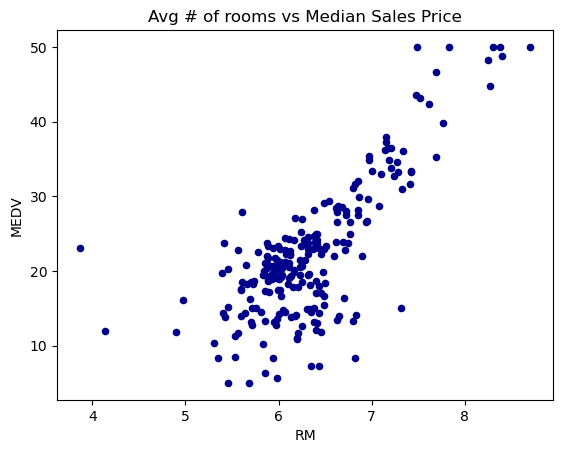

In [20]:
# Scatterplots of MEDV and RM, LSTAT, PTRATIO
train.plot.scatter(x = 'RM', y = 'MEDV', c = 'DarkBlue', title = 'Avg # of rooms vs Median Sales Price')

<Axes: title={'center': '% lower status of the Pop. vs Median Sales Price'}, xlabel='LSTAT', ylabel='MEDV'>

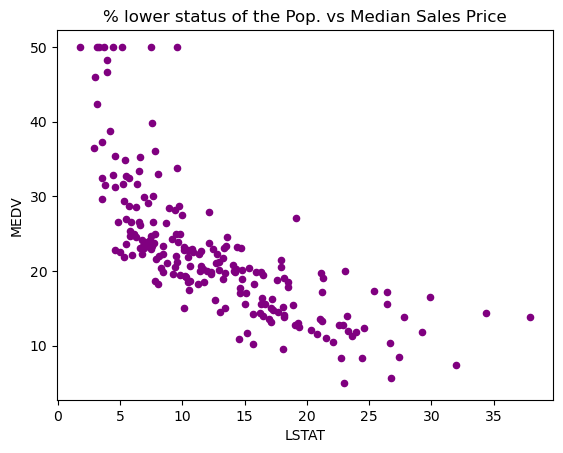

In [21]:
train.plot.scatter(x = 'LSTAT', y = 'MEDV', c = 'Purple', title = '% lower status of the Pop. vs Median Sales Price')

<Axes: title={'center': 'Pupil-Teacher ratio by town vs Median Sales Price'}, xlabel='PTRATIO', ylabel='MEDV'>

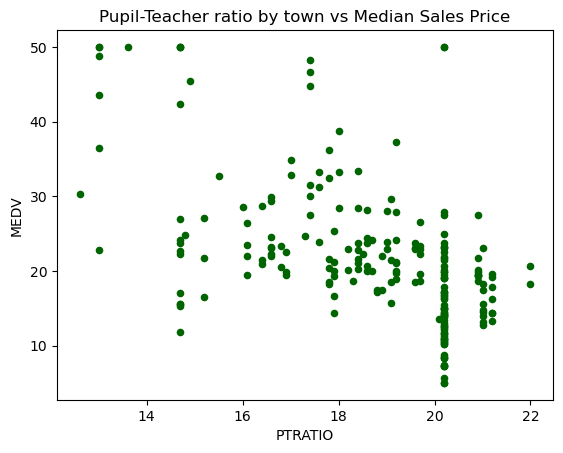

In [22]:
train.plot.scatter(x = 'PTRATIO', y = 'MEDV', c = 'DarkGreen', title = "Pupil-Teacher ratio by town vs Median Sales Price")

<Axes: title={'center': 'Full-Value Property-tax rate per 10,000 dollars vs Median Sales Price'}, xlabel='TAX', ylabel='MEDV'>

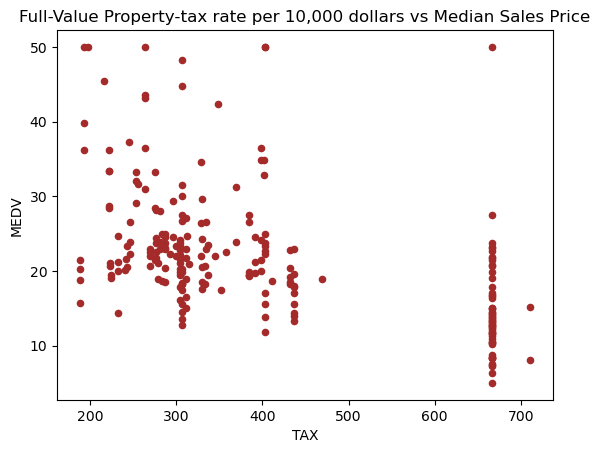

In [23]:
train.plot.scatter(x = 'TAX', y = 'MEDV', c = 'Brown', title = "Full-Value Property-tax rate per 10,000 dollars vs Median Sales Price")

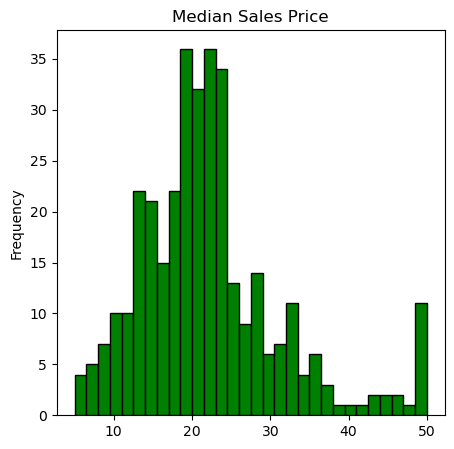

In [24]:
# Histogram of MEDV
train['MEDV'].plot(kind = 'hist', y = 'MEDV', color = 'g', edgecolor = 'k', title = 'Median Sales Price', figsize =(5,5), bins = 30);

# Correlation Matrix
Which feature Values are correlated.  For highly correlated values you will need to remove one of the columns.
- Display the correl_matrix variable
- Assign 'MEDV' from the train data set to the variable y.
- Drop 'MEDV' from the train data set with axis = 1 and without the inplace parameter assign it to the variable X.
- Assign 'MEDV' from the test data set to the variable y_test.
- Drop 'MEDV' from the test data set with axis = 1 and without the inplace parameter assign it to the variable X_test.

In [25]:
# Correlation Matrix
correl_matrix

,CRIM,ZN,NOX,RM,AGE,DIS,TAX,PTRATIO,LSTAT,MEDV
CRIM,1.000000,-0.200811,0.436472,-0.249513,0.348863,-0.399184,0.601923,0.296669,0.449113,-0.389653
ZN,-0.200811,1.000000,-0.501968,0.233500,-0.517021,0.650440,-0.292299,-0.354287,-0.364155,0.320068
NOX,0.436472,-0.501968,1.000000,-0.201315,0.708433,-0.770322,0.687807,0.213131,0.635093,-0.435318
RM,-0.249513,0.233500,-0.201315,1.000000,-0.103742,0.101722,-0.223368,-0.444425,-0.557178,0.761446
AGE,0.348863,-0.517021,0.708433,-0.103742,1.000000,-0.735562,0.555246,0.253714,0.618230,-0.367522
DIS,-0.399184,0.650440,-0.770322,0.101722,-0.735562,1.000000,-0.585208,-0.236078,-0.480815,0.250614
TAX,0.601923,-0.292299,0.687807,-0.223368,0.555246,-0.585208,1.000000,0.497924,0.557264,-0.522640
PTRATIO,0.296669,-0.354287,0.213131,-0.444425,0.253714,-0.236078,0.497924,1.000000,0.384398,-0.564165
LSTAT,0.449113,-0.364155,0.635093,-0.557178,0.618230,-0.480815,0.557264,0.384398,1.000000,-0.729024
MEDV,-0.389653,0.320068,-0.435318,0.761446,-0.367522,0.250614,-0.522640,-0.564165,-0.729024,1.000000


# Question 1 - Separate the Features and target variable
- Create target column 'MEDV' for train data set assign to y variable
- Create feature columns by dropping 'MEDV' and assign to X variable
- Create target column 'MEDV' for test data set assign to y_test variable
- Create feature columns by dropping 'MEDV' and assign to X_test variable

# Dealing with Missing Numerical Values
The SimpleImputer function is used to replace the missing values. In the numeric columns we must decide how they will be replaced. We will replace missing values with the median value. <br><br>
A pipeline is a series of steps that the data set goes through the prepare the data to create a model. <br>

# Question 2 - Creating a Pipeline for Numerical data
- from sklearn.impute import SimpleImputer
- from sklearn.preprocessing import StandardScaler, RobustScaler
- from sklearn.preprocessing import OneHotEncoder
- from sklearn.pipeline import Pipeline
- Create number features from X that are np.number put it in a variable numeric_features
- Create a Pipeline called numeric_transformer 
-        that imputes the missing values with median 
-        and scaler with the StandardScaler

# Question 3 - Missing Categorical Values 
Creating pipeline for Categorical columns<br>
- Create a list of all the 'object' called categorical_features
- Create a categorical Pipeline called categorical_transformer 
-         that impute missing values using SimpleImputer strategy equal to "most_frequent" 
-         and onehot OneHotEncoder with handle_unknown= "ignore"

# Question 4 - Create the data preprocessing pipeline
Use the code below to create the data preprocessing pipeline.
- from sklearn.compose import ColumnTransformer
- Create a ColumnTransformer called preprocessor
-         name 'num' the numeric_transformer and called the numeric_features
-         name 'cat', the categorical_transformer, categorical_features

# Model building
Since we are trying to predict total price as a continuous value, we will fit a regression model.  There are several different models.  
- **Multiple Linear Regression**
This week, you will create all the models above using the Boston Housing Data. We will also evaluate the models using cross-validation.

# Question 5 - Linear Regression Model - Standard Scaler
- from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
- from sklearn.linear_model import LinearRegression
- from sklearn.metrics import mean_squared_error, r2_score
- create a make_pipeline(preprocessor called lin_reg, TransformedTargetRegressor(LinearRegression(), transformer is StandardScaler()
- fit the lin_reg with X features and y target
- create y_pred from lin_reg with predict X
- create mean_squared_error with y and y_pred parameters raised to 0.5 called lin_reg_rmse_train
- create y_pred_test as the lin_reg.predict for X_test
- credit the lin_reg_rmse_test as mean_squared_error for y_test, and y_pred_test raised to 0.5
- print "StandardScaler"
- print "Training ", lin_reg_rmse_train
- print "Testing ", lin_reg_rmse_test

# Question 6 - Cross Validation
- from sklearn.model_selection import KFold, cross_val_score, GridSearchCV
- from sklearn.linear_model import Ridge, Lasso, ElasticNet
- from sklearn.ensemble import RandomForestRegressor
- Assign ""neg_root_mean_squared_error" to the varible sc
- create the cross_val_score * -1 raised to the 0.5 power and assign it to lin_rmses_cv for training data.
- create the cross_val_score * -1 raised to the 0.5 power and assign it to lin_rmse_cv_test for the test data.
- print "5-Fold Cross Validation"
- print "train data set RMSE
- print pd.Series(l_rmse_cv describe method)
- print test data set RMSE to the next line
- print pd.Series(l_rmse_cv_test describe method)

# Question 7 - Ridge Regression
- create a dictionary key 'transformedtargetregressor__regressor__alpha' and list [0.1, 0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 10.0, 100.0]
- make a pipeline with the preprocessor, TransforemedTargetRegressor Ridge(), transformer =  StandardScaler()) called rid_reg
- create a GridSearchCV with rid_reg, param_grid, cv as 5 fold, scoring = sc
- grid_search.fit(X, y)
- grid_search.best_index called best_index
- print "Best Alpha found" gird_search.best_params_
- best_alpha_value is grid_search.best_params_['transformedtargetregressor__regressor__alpha']]

# Question 8 - Ridge Regression Cross Validation
- Make a Ridge regression pipeline with new alpha = best_alpha value and transformer = StandardScaler() called rid_rmse_cv
- create the square root of -1 * cross_val_score of the r_reg, X, y, scoring = sc, cv = 5 assign to variable rid_rmse_cv
- create the square root of -1 * cross_val_score of the r_reg, X_test, y_test, scoring = sc, cv = 5 assign to variable rid_rmse_cv_test
- print "Ridge Regression"
- print "Training Data\n", pd.Series(rid_rmse_cv).describe()
- print "Testing Data\n", pd.Series(rid_rmse_cv_test).describe()


# Question 9 - Lasso Regression - Best Parameter
- Create a pipeline of preprocessor, TransformedTargetRegressor Lasso(), transformer = StandardScaler() called lasso_reg
- Create the GridSearchCV with lasso_reg, param_grid, cv = 5, scoring = sc assigned to variable grid_search
- Fit the grid_search with X and y
- Create the grid_search.best_index assigned to best_index
- print "Best Alpha found: ", grid_search.best_params_
- Assign grid_search.best_params_['transformedtargetregressor__regressor__alpha'] to best_alpha_value


# Question 10 - Lasso Regression Cross-Validate
- Create a pipeline of preprocessor, TransformedTargetRegressor Lasso(alpha = best_alpha_value), transformer = StandardScaler() called lasso_reg
- Take the np.sqrt of -1 * cross_val_score of lasso_reg, X, y, scoring = sc, cv = 5 assign it to the variable lasso_rmse_cv
- Take the np.sqrt of -1 * cross_val_score of lasso_reg, X_test, y_test, scoring = sc, cv = 5 assign it to the variable lasso_rmse_cv_test
- print "Lasso Regression"
- print "Training Data\n", pd.Series(lasso_rmse_cv).descibe()
- print "Testing Data\n", pd.Series(lasso_rmse_cv_test).describe()

# Question 12 Elastic Net Regression
- Create a pipeline with preprocessor, 
     TransformedTargetRegressor(regressor = ElasticNet(), 
     transformer = StandardScaler())) assigned to en_reg
- Create a list called A1 = [0.1, 0.25, 0.50, 1.0, 1.1, 1.25, 1.5, 5.0, 10.0]
- Create a list called L1 = [0.1, 0.2, 0.25, 0.30, 0.35, 0.40, 0.5, 0.75, 0.8]
- Create a param_grid = {
    'transformedtargetregressor__regressor__alpha' : A1,
     'transformedtargetregressor__regressor__l1_ratio' : L1}
- Create the GridSearchCV with en_reg, param_grid, cv = 5, scoring = sc
- grid_search.fit(X, y)
- Assign grid_search.best_params_ to best_params
- Convert the best_params['transformedtargetregressor__regressor__alpha'] to a float and assign it to best_alpha
- Convert the best_params['transformedtargetregressor__regressor__l1_ratio'] to a float and assign it to best_l1
- print the "best alpha ", best_alpha
- print the "best l1", best_l1   

# Question 12 Elastic Net Regression - Cross Validation
- Create a Pipeline with preprocessor,
              TransformedTargetRegressor(ElasticNet(alpha = best_alpha, l1_ratio = best_l1),
              transformer = StandardScaler()))
- Create the GridSearchCV en_reg, parm_grid, cv = 5, scoring = sc assign to variable grid_search
- Fit the grid_search X, and y
- Assign grid_search.best_params to best_params
- Convert the best_params['transformedtargetregressor__regressor__alpha'] to float and assign it to best_alpha
- Convert the best_params['transformedtargetregressor__regressor__l1_ratio'] to a float and assign it to best_l1
- print "best alpha", best_alpha
- print "best l1", best_l1

# Question 13 - Random Forest Regression - Cross Validatiaon
- Create a pipeline with preprocessor,
         TransformedTargetRegressor(RandomForestRegressor(random_state=42), 
         transformer = StandardScaler()))
- Create the cross_val_score with rf_reg, X, y, scoring = sc, cv = 5  assign it to rf_rmse
- Create the cross_val_score with rf_reg, X_test, y_test, scoring = sc, cv = 5 assign it to rf_rmse_test
- print "Random Forest Regression"
- print "Training Data\n", pd.Series(rf_rmse).describe()
- print "Testing Data\n",  pd.Series(rf_rmse_test).describe()

Here is a clear, simple interpretation of your numbers.

Your results  
• Model 1:  
  – RMSE = 6.22  
  – Mean MEDV = 22.62  

• Model 2:  
  – RMSE = 6.33  
  – Mean MEDV = 22.21  

Percentage error  
Model 1:  
$$
\frac{100 * 6.22}{22.62} \approx 27.5
$$  
≈ 27.5% average error

Model 2:  
$$
\frac{100 * 6.33}{22.21} \approx 28.5
$$  
≈ 28.5% average error

What this means  
• Both models have almost the same level of accuracy  
• Both are off by about 27–29% on average  
• For basic multiple linear regression on the Boston Housing dataset, this is normal  
• These numbers are acceptable for teaching, but not great for real‑world prediction

How to interpret quality  
• < 20% error → small error  
• 20–30% error → medium error  
• > 30% - 50% error → big error<br>
• > 50% error → very big error

# Comparing Train and Test RSME values
Here is a simple, clear way to explain “how close is close” when comparing training RMSE and testing RMSE.

How Close Should Training and Testing RMSE Be?

A good rule of thumb:

• If the testing RMSE is within 10–20% of the training RMSE, they are considered close.  
• This means normal, healthy model behavior.

Examples of “close” RMSE values

Training RMSE = 6.0  
Testing RMSE = 6.3  

Difference:  
$$
\frac{6.3 - 6.0}{6.0} = 0.05
$$  
5% difference → very close (good model)

Another example:

Training RMSE = 6.0  
Testing RMSE = 7.0  

Difference:  
$$
\frac{7.0 - 6.0}{6.0} = 0.17
$$  
17% difference → still acceptable

Examples of NOT close

Training RMSE = 4.0  
Testing RMSE = 7.5  

Difference:  
$$
\frac{7.5 - 4.0}{4.0} = 0.875
$$  
87% difference → not close at all  
→ clear overfitting

Student‑friendly guidelines

• 0–10% difference → very close (good fit)  
• 10–20% difference → close enough (still good)  
• 20–30% difference → warning zone  
• 30%+ difference → model is likely overfitting

If you want, I can also create:
• a discussion prompt using your class’s RMSE values  
• a simple chart to show “close vs not close” visually  
• a worksheet for students to calculate % differences themselves